Tamil Nadu Election 2026 Analysis

Research Questions:
1. Margin Analysis
2. Vote Share Analysis
3. Seat Flip Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
results_2021 = pd.read_csv('/content/tn_2021_results.csv')

results_2026 = pd.read_csv('/content/tn_2026_results.csv')

master = pd.read_csv('/content/constituency_master.csv')

print(results_2026.head())

    constituency  ac_number         candidate   party  votes  turnout  \
0  Gummidipoondi          1     S.VIJAYAKUMAR     TVK  94320      NaN   
1  Gummidipoondi          1        SUDHAKAR.V  AIADMK  66375      NaN   
2  Gummidipoondi          1  T.J.GOVINDARAJAN     DMK  62492      NaN   
3  Gummidipoondi          1   R.SRIDAR. B.L.,     NTK   4756      NaN   
4  Gummidipoondi          1              NOTA    NOTA    937      NaN   

  reserved         region  
0      GEN  Chennai Metro  
1      GEN  Chennai Metro  
2      GEN  Chennai Metro  
3      GEN  Chennai Metro  
4      GEN  Chennai Metro  


Dataset Overview

In [4]:
print(results_2026.info())

print(results_2026.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4257 non-null   object 
 1   ac_number     4257 non-null   int64  
 2   candidate     4257 non-null   object 
 3   party         4257 non-null   object 
 4   votes         4257 non-null   int64  
 5   turnout       0 non-null      float64
 6   reserved      4257 non-null   object 
 7   region        4257 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 266.2+ KB
None
         ac_number          votes  turnout
count  4257.000000    4257.000000      0.0
mean    112.949965   11586.591731      NaN
std      68.293502   25786.948660      NaN
min       1.000000       2.000000      NaN
25%      54.000000     122.000000      NaN
50%     113.000000     271.000000      NaN
75%     172.000000    1031.000000      NaN
max     234.000000  220382.000000      NaN


Q6: Margin Analysis

In [6]:
grouped_results = results_2026.sort_values(by=['constituency', 'votes'], ascending=[True, False])
winner_runnerup = grouped_results.groupby('constituency').head(2)

# Pivot the table to get winner and runnerup votes in separate columns
winner_runnerup_pivot = winner_runnerup.groupby(['constituency', winner_runnerup.groupby('constituency').cumcount()]).agg(votes=('votes', 'first')).unstack(fill_value=0)
winner_runnerup_pivot.columns = ['winner_votes', 'runnerup_votes']
winner_runnerup_pivot = winner_runnerup_pivot.reset_index()

# Merge margin back to the original results_2026 for consistency if needed, or calculate directly
constituency_margins = winner_runnerup_pivot.copy()
constituency_margins['margin'] = constituency_margins['winner_votes'] - constituency_margins['runnerup_votes']

close_seats = constituency_margins[constituency_margins['margin'] < 2000]

print(close_seats[['constituency', 'margin']])

        constituency  margin
9           Anthiyur    1260
37            Cumbum     751
40          Dindigul    1131
60      Kallakurichi     798
63     Kanniyakumari     214
65             Karur    1821
69         Killiyoor    1311
75        Kovilpatti     843
78        Kulithalai     579
80        Kumbakonam     679
95       Manamadurai    1208
96        Manapparai    1426
97        Mannargudi    1566
120           Palani     693
125        Papanasam    1065
128  Paramathi-Velur     308
137            Polur     227
141      Pudukkottai    1867
167     Srivaikuntam    1186
176       Thirumayam    1492
191       Tindivanam     734
197     Tirukkoyilur     285
206   Udhagamandalam     976
209      Usilampatti    1805
222     Veppanahalli     138
223       Vikravandi     910


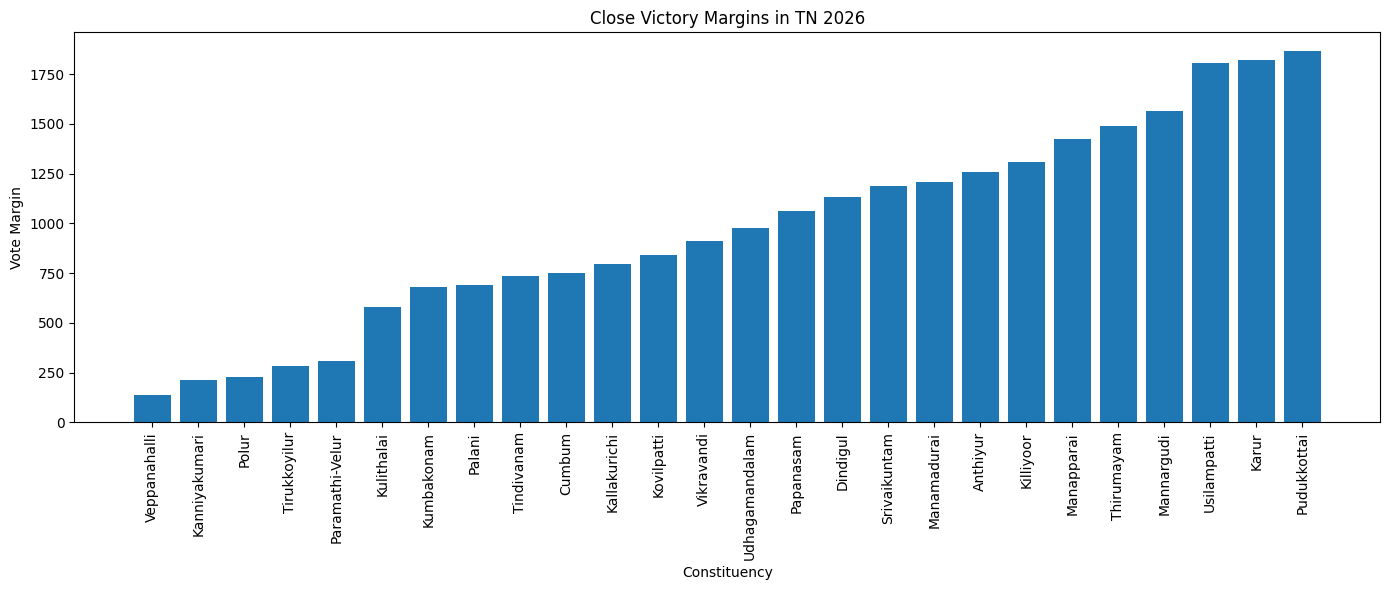

In [7]:
plt.figure(figsize=(14,6))

close_seats = close_seats.sort_values('margin')

plt.bar(
    close_seats['constituency'],
    close_seats['margin']
)

plt.title("Close Victory Margins in TN 2026")

plt.xlabel("Constituency")

plt.ylabel("Vote Margin")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [8]:
plt.savefig(
    "margin_chart.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

Q3: Vote Share Analysis

In [9]:
vote_share = results_2026.groupby('party')['votes'].sum()

print(vote_share)

party
AIADMK                                                  10462146
ALL PENSIONER'S PARTY                                         55
AMMK                                                      425345
Aanaithinthiya Jananayaka Pathukappu Kazhagam              22964
Ahila India Dhayaga Makkal Munnetra Katchi                   283
                                                          ...   
Veerath Thiyagi Viswanathadoss Thozhilalarkal Katchi        5624
Vidial Valarchi Perani                                       235
Viduthalai Kalam Katchi                                      211
Viro Ke Vir Indian Party                                     498
Vishwa Tamil Kazhagam                                       3576
Name: votes, Length: 105, dtype: int64


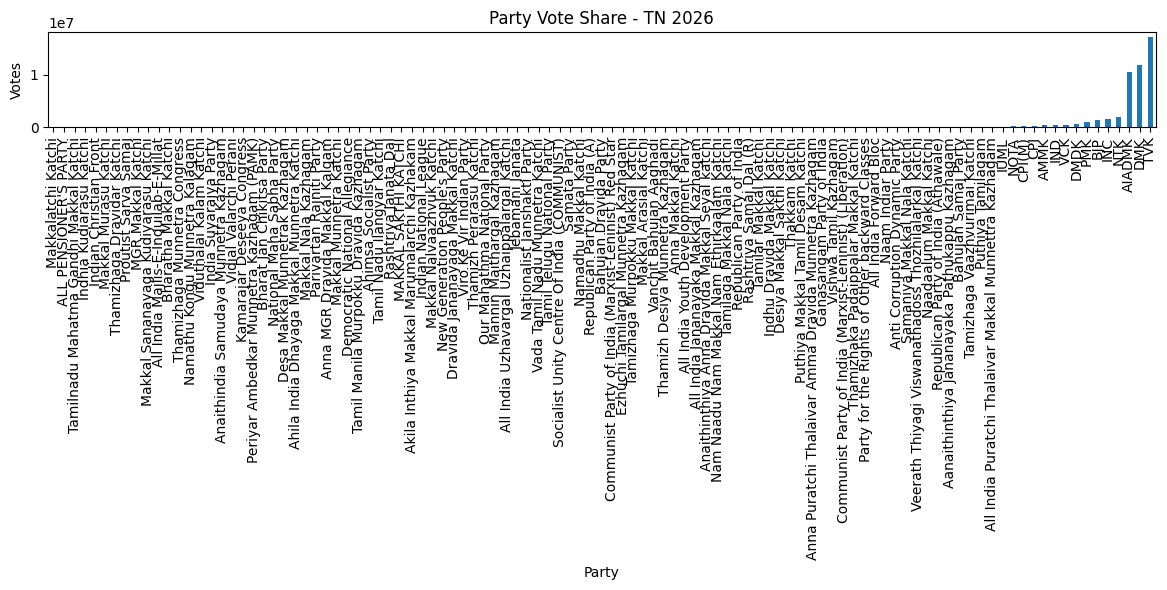

In [10]:
vote_share.sort_values().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Party Vote Share - TN 2026")

plt.xlabel("Party")

plt.ylabel("Votes")

plt.tight_layout()

plt.show()

Q2: Seat Flip Analysis

In [12]:
winner_2021 = results_2021.loc[results_2021.groupby('constituency')['votes'].idxmax()][['constituency', 'party']]
winner_2021 = winner_2021.rename(columns={'party': 'winner_party_2021'})

winner_2026 = results_2026.loc[results_2026.groupby('constituency')['votes'].idxmax()][['constituency', 'party']]
winner_2026 = winner_2026.rename(columns={'party': 'winner_party_2026'})

merged = winner_2021.merge(
    winner_2026,
    on='constituency'
)

flips = merged[
    merged['winner_party_2021']
    !=
    merged['winner_party_2026']
]

print(flips)

      constituency winner_party_2021 winner_party_2026
0          Alandur               DMK               TVK
2        Alangulam            AIADMK               DMK
4         Ambattur               DMK               TVK
6        Anaikattu               DMK            AIADMK
8       Anna Nagar               DMK               TVK
..             ...               ...               ...
190     Vikravandi               DMK               PMK
193    Villivakkam               DMK               TVK
195   Virudhunagar               DMK               TVK
196  Virugampakkam               DMK               TVK
197  Vriddhachalam               INC              DMDK

[143 rows x 3 columns]


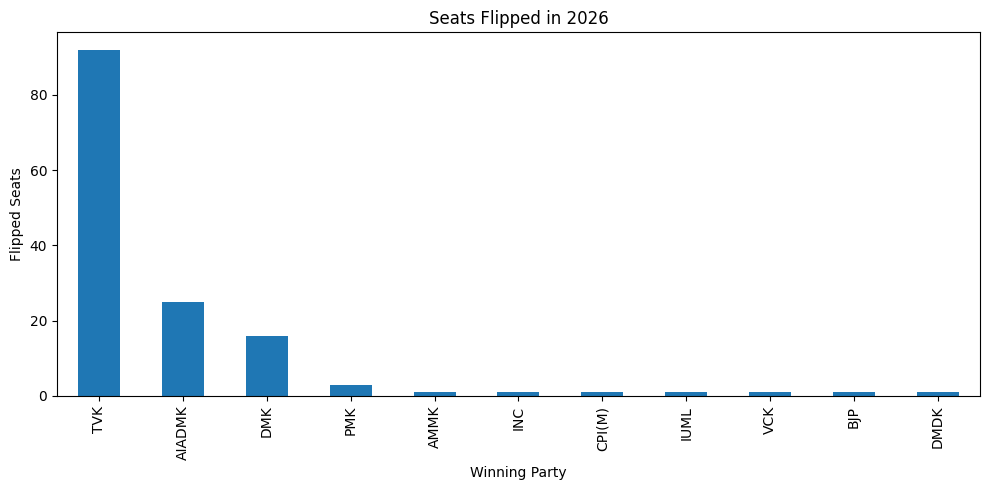

In [13]:
flip_counts = flips[
    'winner_party_2026'
].value_counts()

flip_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Seats Flipped in 2026")

plt.xlabel("Winning Party")

plt.ylabel("Flipped Seats")

plt.tight_layout()

plt.show()

Summary Statistics

In [15]:
print("Total constituencies:",
      len(results_2026))

print("Total close contests:",
      len(close_seats))

print("Closest margin:",
      close_seats['margin'].min())

print("Average margin:",
      constituency_margins['margin'].mean())

print("Total flipped seats:",
      len(flips))

Total constituencies: 4257
Total close contests: 26
Closest margin: 138
Average margin: 16742.369098712446
Total flipped seats: 143


Final Insights

1. Several constituencies had very small victory margins.

2. A large number of seats changed political control.

3. Vote-share distribution strongly influenced seat outcomes.